In [74]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Plotting_IQR import plot_distribution, get_training_data, plot_pfn_variance_surface, plot_GP_variance_surface
from pfn_evaluate import eval_pfn
import pfns4bo
from pfns4bo.scripts.acquisition_functions import TransformerBOMethod

In [ ]:
# Load data
file_path = "LS_1D_varied_results/run_20260803_015025/metrics.pt"
metrics = torch.load(file_path)

file_path = "LS_1D_varied_results/run_20260803_015025/experimental_results.pt"
data = torch.load(file_path)

In [ ]:
#metrics = {
#        "pred_error": torch.zeros((n_tests, n_dims, n_methods, n_repeats, n_samples, n_fns)), # GP & PFN only
#        "total_error": torch.zeros((n_tests, n_dims, n_methods, n_repeats, 1)),
#        "EI": torch.zeros((n_tests, n_dims, n_methods, n_repeats, n_samples, 1))
#    }
pred_error = metrics["pred_error"]
total_error = metrics["total_error"]
ei = metrics["EI"]
gll = metrics["GLL"]
m_gll = metrics["MGLL"]

y_true_store = data["y_true"][0]
mu_store = data["mu"][0]
var_store = data["var"][0]
x_queried = data["x_query"][0]

ls_arr = data["lengthscales"]

In [ ]:
mu_data_GP = torch.sum(mu_store[:, 0, 0, :, :], dim=-1, keepdim=True)
mu_data_PFN = torch.sum(mu_store[:, 1, 0, :, :], dim=-1, keepdim=True)
mu_data_PFN_W = torch.sum(mu_store[:, 2, 0, :, :], dim=-1, keepdim=True)
var_data_GP = torch.sum(var_store[:, 0, 0, :, :], dim=-1, keepdim=True)
var_data_PFN = torch.sum(var_store[:, 1, 0, :, :], dim=-1, keepdim=True)
var_data_PFN_W = torch.sum(var_store[:, 2, 0, :, :], dim=-1, keepdim=True)
x_query_GP = x_queried[:, 0, 0, :, :]
x_query_PFN = x_queried[:, 1, 0, :, :]
x_query_PFN_W = x_queried[:, 2, 0, :, :]
y_true_arr = y_true_store[:, 0, 0, :, :]

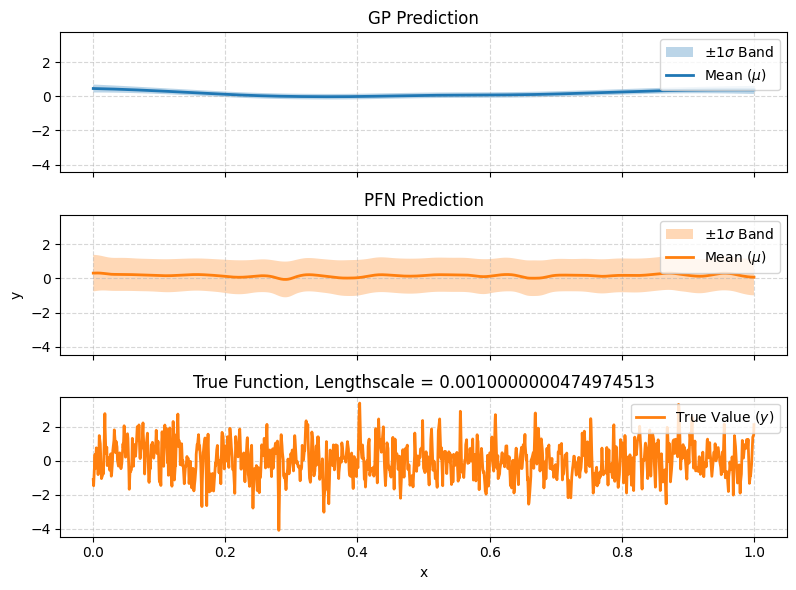

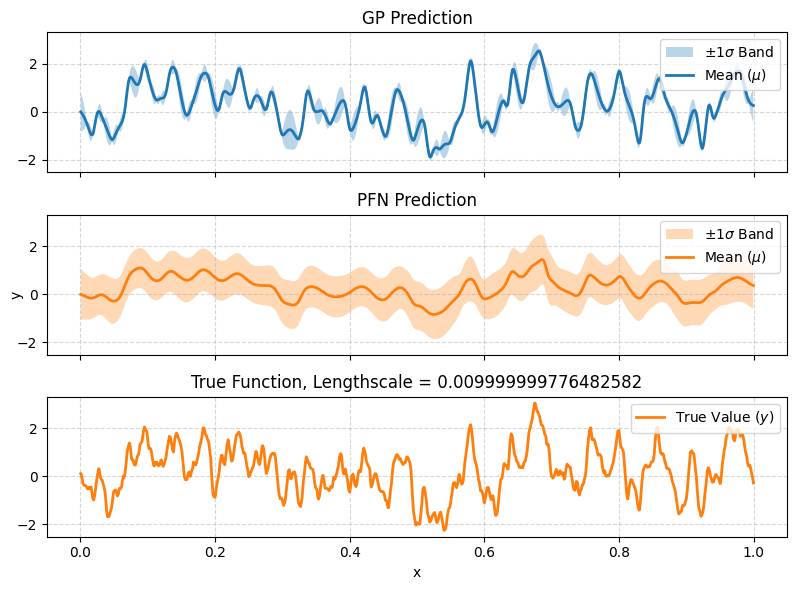

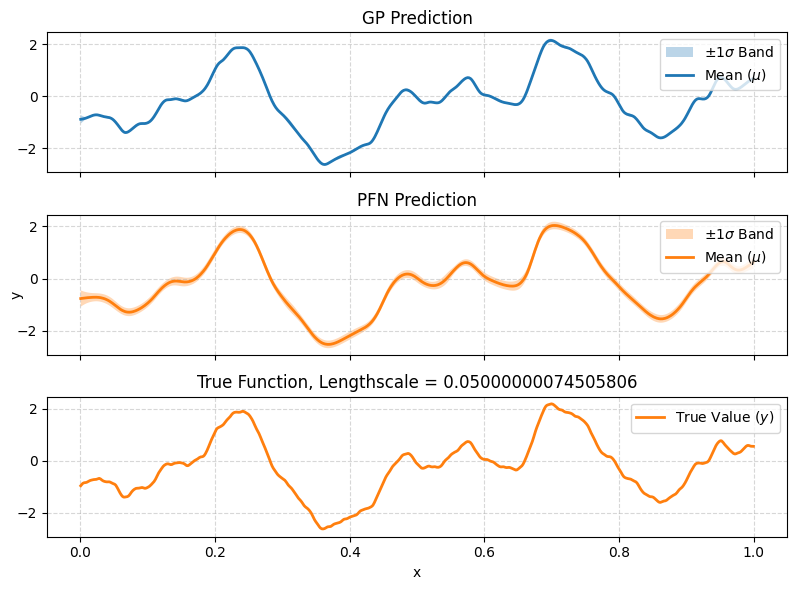

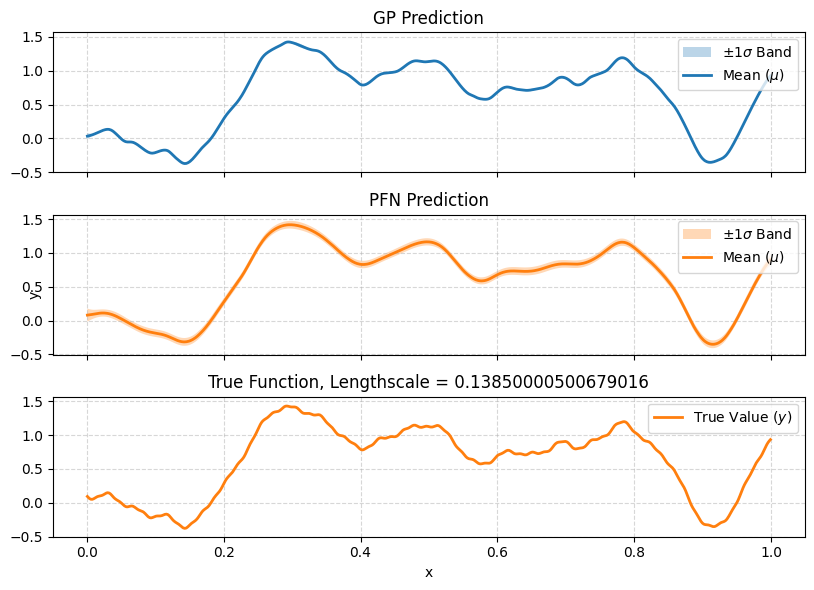

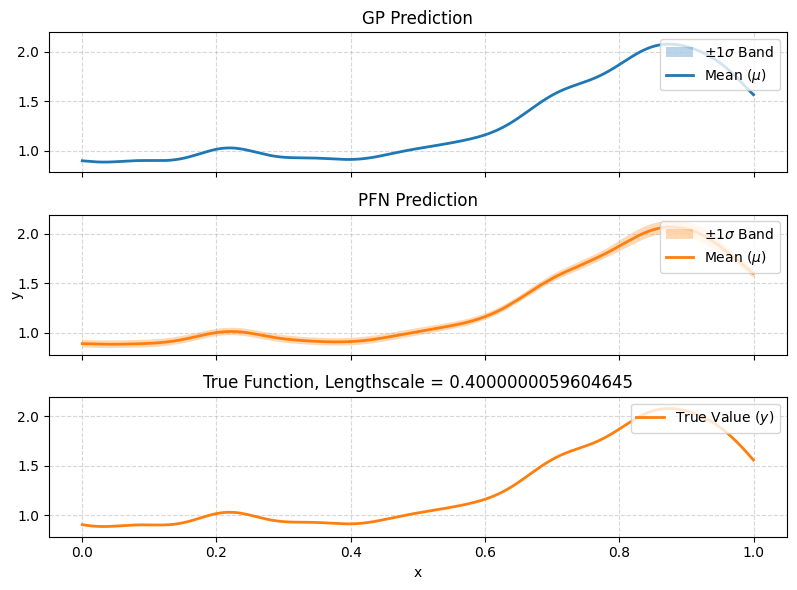

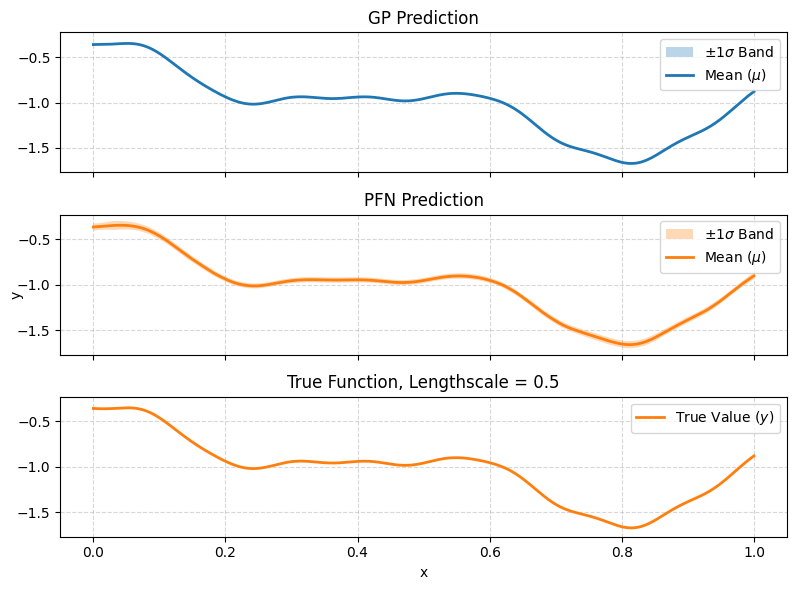

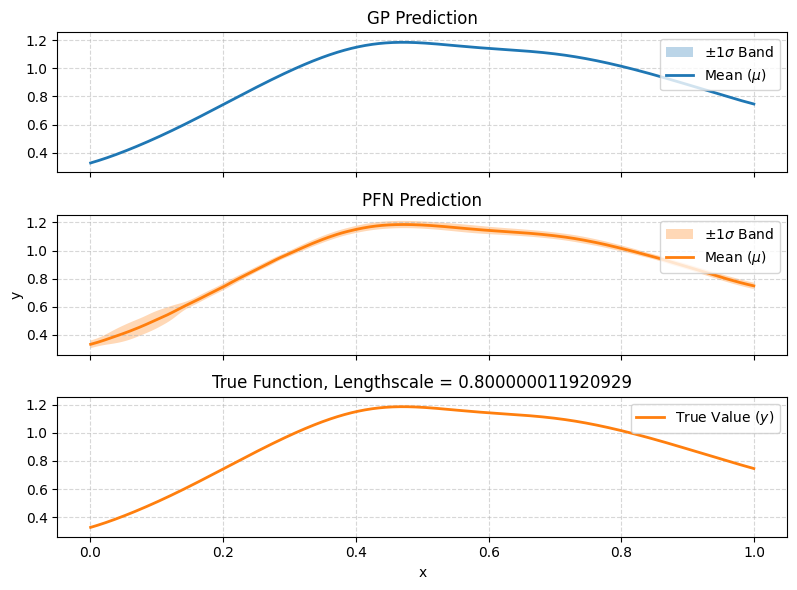

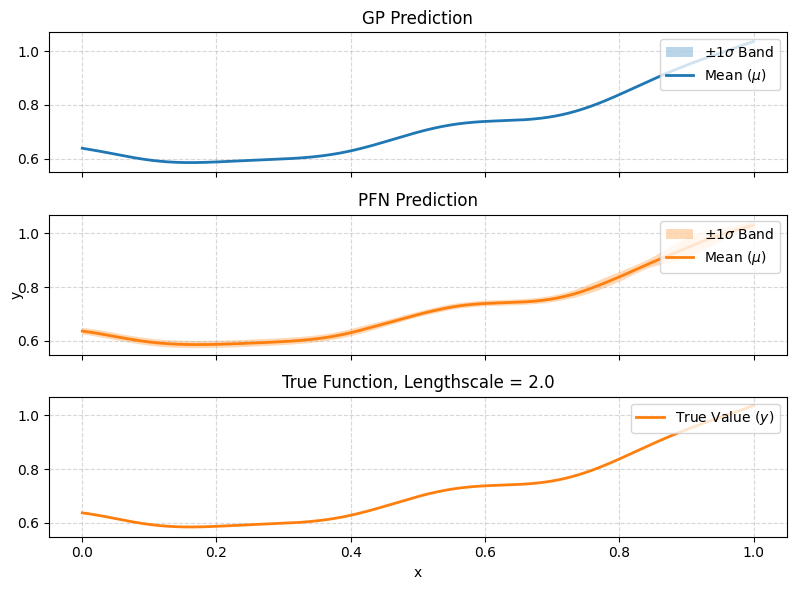

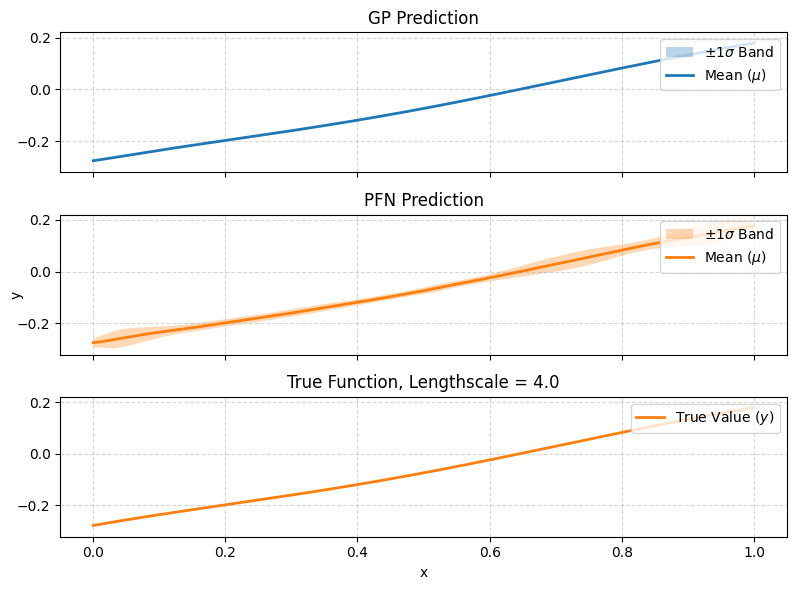

In [ ]:
for i in range(mu_data_GP.shape[0]):
    ls = ls_arr[0][i]
    
    y_true = y_true_arr[i].squeeze(-1)
    
    pred_ub_GP = (mu_data_GP[i] + torch.sqrt(var_data_GP[i]) * 1).squeeze(-1)
    pred_lb_GP = (mu_data_GP[i] - torch.sqrt(var_data_GP[i]) * 1).squeeze(-1)
    pred_ub_PFN = (mu_data_PFN[i] + torch.sqrt(var_data_PFN[i]) * 1).squeeze(-1)
    pred_lb_PFN = (mu_data_PFN[i] - torch.sqrt(var_data_PFN[i]) * 1).squeeze(-1)
    pred_ub_PFN_W = (mu_data_PFN_W[i] + torch.sqrt(var_data_PFN_W[i]) * 1).squeeze(-1)
    pred_lb_PFN_W = (mu_data_PFN_W[i] - torch.sqrt(var_data_PFN_W[i]) * 1).squeeze(-1)

    x_query_GP_plot = x_query_GP[i].squeeze(-1)
    x_query_PFN_plot = x_query_PFN[i].squeeze(-1)
    x_query_PFN_W_plot = x_query_PFN_W[i].squeeze(-1)
    mu_GP = mu_data_GP[i].squeeze(-1)
    mu_PFN = mu_data_PFN[i].squeeze(-1)
    mu_PFN_W = mu_data_PFN_W[i].squeeze(-1)

    sort_idx_GP = torch.argsort(x_query_GP_plot)
    x_query_GP_plot = x_query_GP_plot[sort_idx_GP]
    pred_ub_GP = pred_ub_GP[sort_idx_GP]
    pred_lb_GP = pred_lb_GP[sort_idx_GP]
    mu_GP = mu_GP[sort_idx_GP]
    y_true = y_true[sort_idx_GP]

    sort_idx_PFN = torch.argsort(x_query_PFN_plot)
    x_query_PFN_plot = x_query_PFN_plot[sort_idx_PFN]
    pred_ub_PFN = pred_ub_PFN[sort_idx_PFN]
    pred_lb_PFN = pred_lb_PFN[sort_idx_PFN]
    mu_PFN = mu_PFN[sort_idx_PFN]

    sort_idx_PFN_W = torch.argsort(x_query_PFN_W_plot)
    x_query_PFN_W_plot = x_query_PFN_W_plot[sort_idx_PFN_W]
    pred_ub_PFN_W = pred_ub_PFN_W[sort_idx_PFN_W]
    pred_lb_PFN_W = pred_lb_PFN_W[sort_idx_PFN_W]
    mu_PFN_W = mu_PFN_W[sort_idx_PFN_W]

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        sharey=True,
    )
    ax1.fill_between(
        x_query_GP_plot,
        pred_lb_GP,
        pred_ub_GP,
        color="tab:blue",
        alpha=0.3,
        edgecolor="none",
        label="$\pm 1\sigma$ Band",
    )
    ax1.plot(x_query_GP_plot, mu_GP, color="tab:blue", linewidth=2, label="Mean ($\mu$)")
    ax1.set_title("GP Prediction")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper right")

    ax2.fill_between(
        x_query_PFN_plot,
        pred_lb_PFN,
        pred_ub_PFN,
        color="tab:orange",
        alpha=0.3,
        edgecolor="none",
        label="$\pm 1\sigma$ Band",
    )
    ax2.plot(x_query_PFN_plot, mu_PFN, color="tab:orange", linewidth=2, label="Mean ($\mu$)")
    ax2.set_title("PFN Prediction")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc="upper right")

    ax3.fill_between(
        x_query_PFN_W_plot,
        pred_lb_PFN_W,
        pred_ub_PFN_W,
        color="tab:green",
        alpha=0.3,
        edgecolor="none",
        label="$\pm 1\sigma$ Band",
    )
    ax3.plot(x_query_PFN_W_plot, mu_PFN_W, color="tab:green", linewidth=2, label="Mean ($\mu$)")
    ax3.set_title("K-Warped PFN Prediction")
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper right")

    ax4.plot(x_query_GP_plot, y_true, color="tab:orange", linewidth=2, label="True Value ($y$)")
    ax4.set_title(f"True Function, Lengthscale = {ls}")
    ax4.grid(True, linestyle="--", alpha=0.5)
    ax4.legend(loc="upper right")

    ax4.set_xlabel("x")
    fig.text(0.01, 0.5, "y", va="center", rotation="vertical")

    plt.tight_layout()
    plt.show()

In [ ]:
# metrics["pred_error"][test, k, m_idx, rep, :, :]
# 9 tests, 1 dim, 2 methods, 21 reps, 1000 samples, dim = 1 -> 9 tests, 3 methods, 1000 samples, 1 
pred_error_med = torch.quantile(torch.sum(pred_error[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.5, dim=-3)
total_error_med = torch.quantile(total_error[:, 0, :, :, :], 0.5, dim=-3)
ei_med = torch.quantile(torch.sum(ei[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.5, dim=-3)

pred_error_lq = torch.quantile(torch.sum(pred_error[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.25, dim=-3)
total_error_lq = torch.quantile(total_error[:, 0, :, :, :], 0.25, dim=-3)
ei_lq = torch.quantile(torch.sum(ei[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.25, dim=-3)

pred_error_uq = torch.quantile(torch.sum(pred_error[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.75, dim=-3)
total_error_uq = torch.quantile(total_error[:, 0, :, :, :], 0.75, dim=-3)
ei_uq = torch.quantile(torch.sum(ei[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.75, dim=-3)

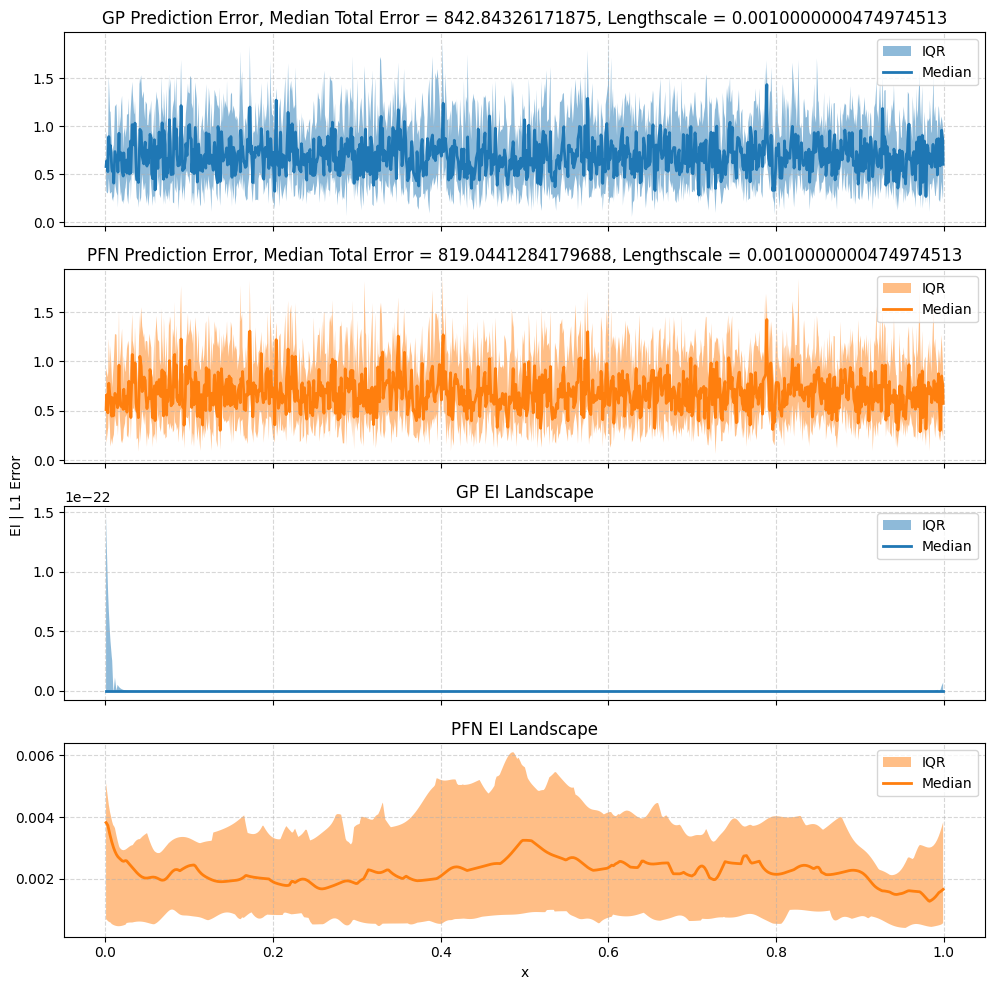

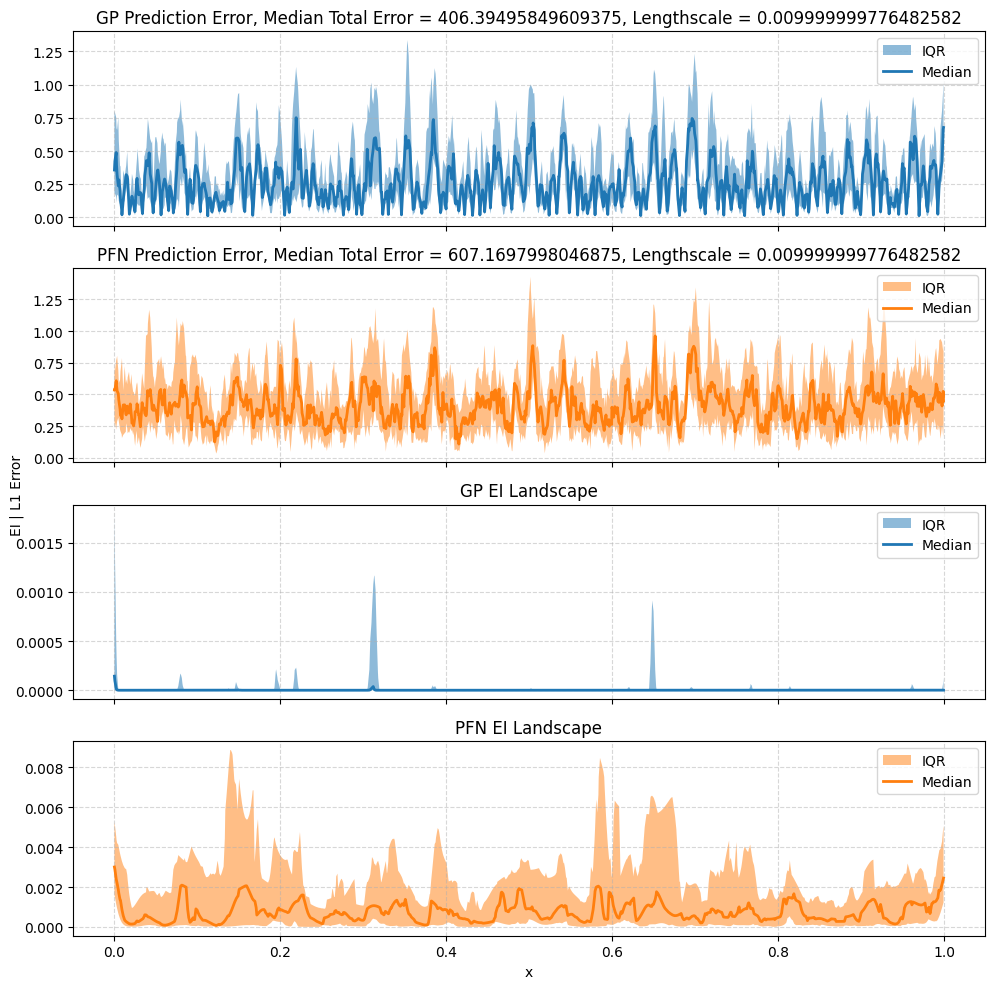

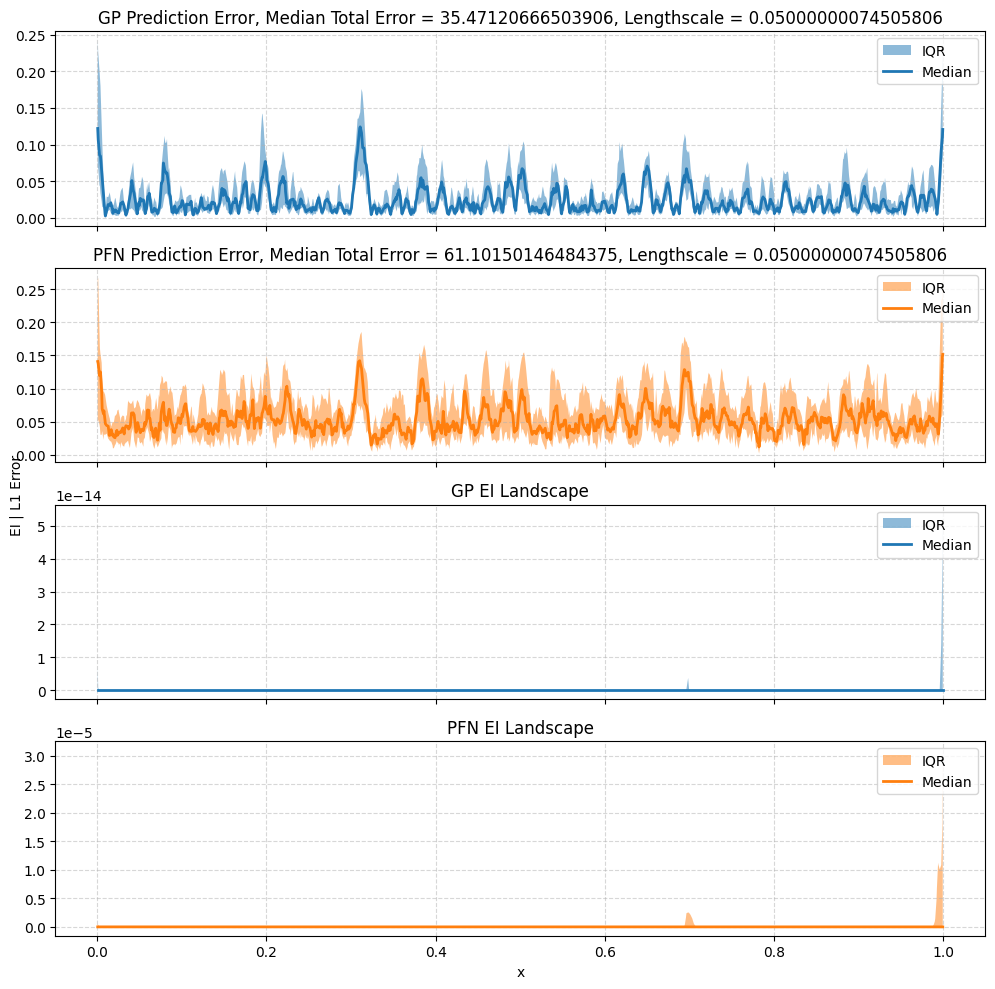

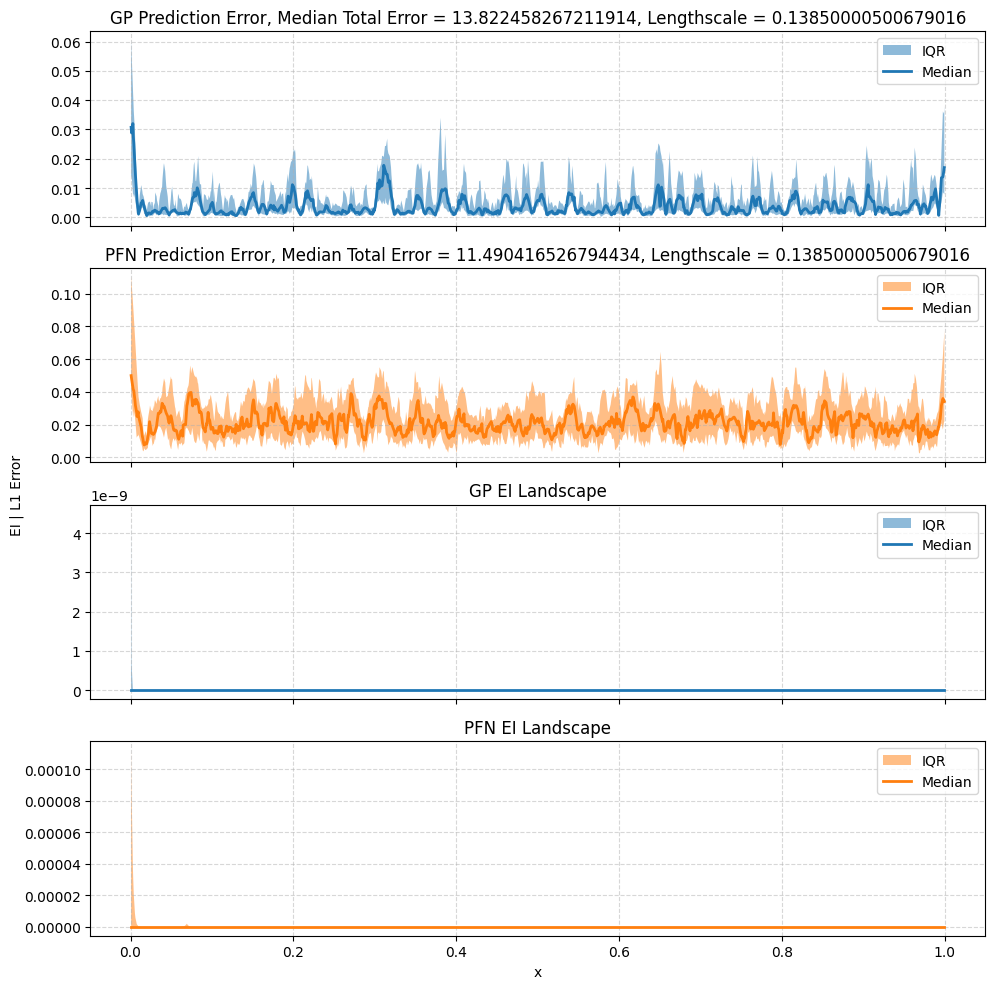

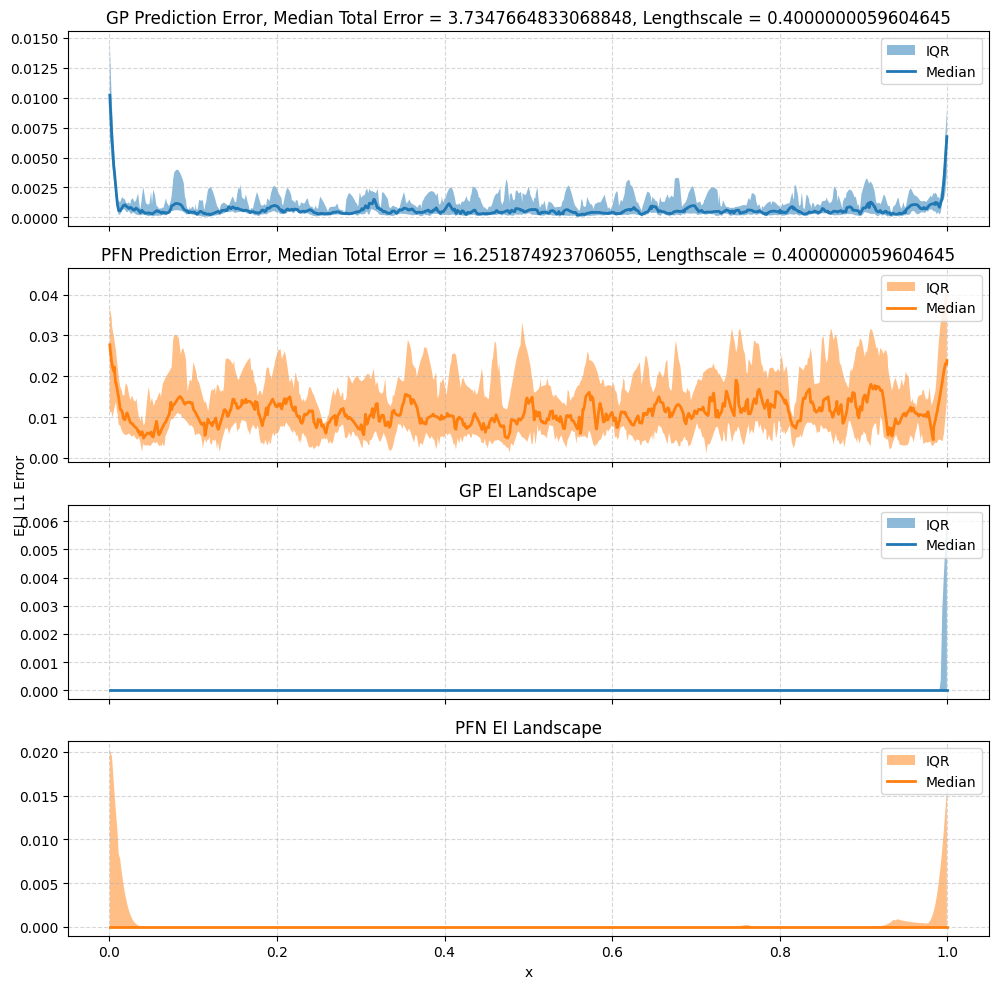

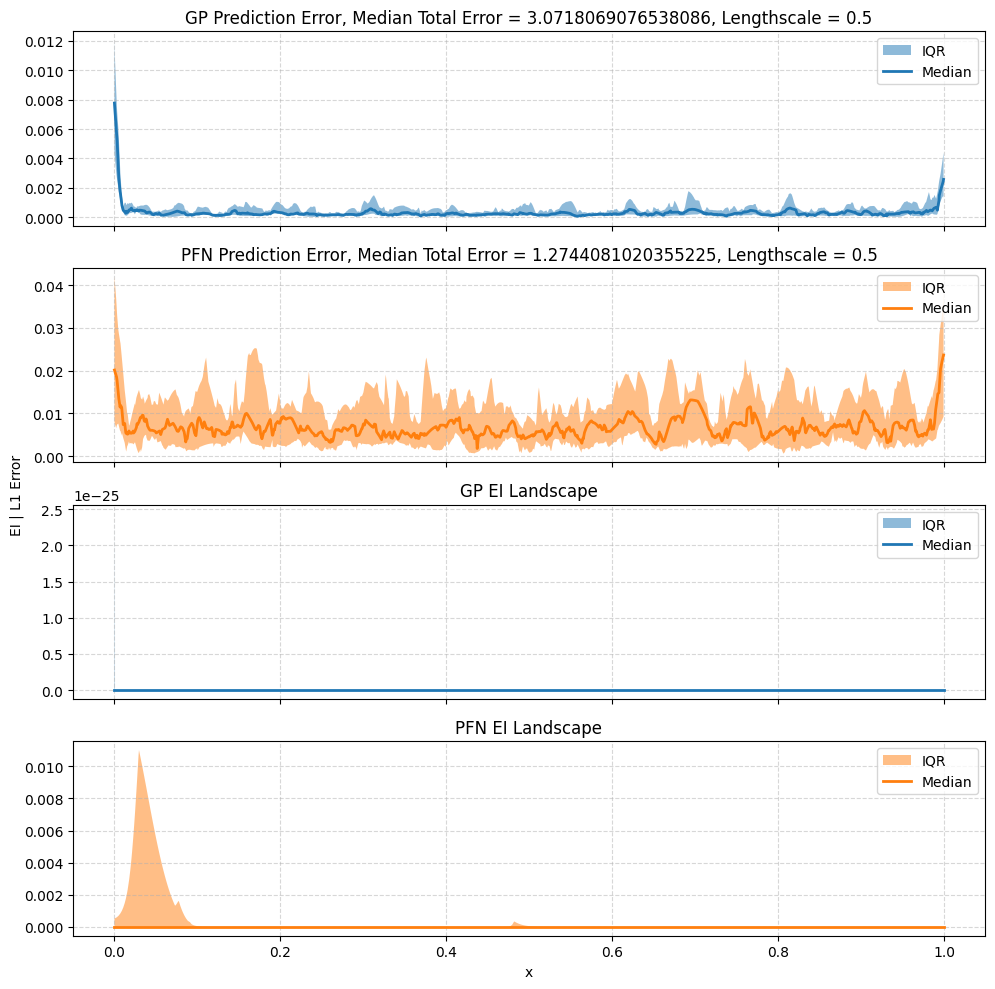

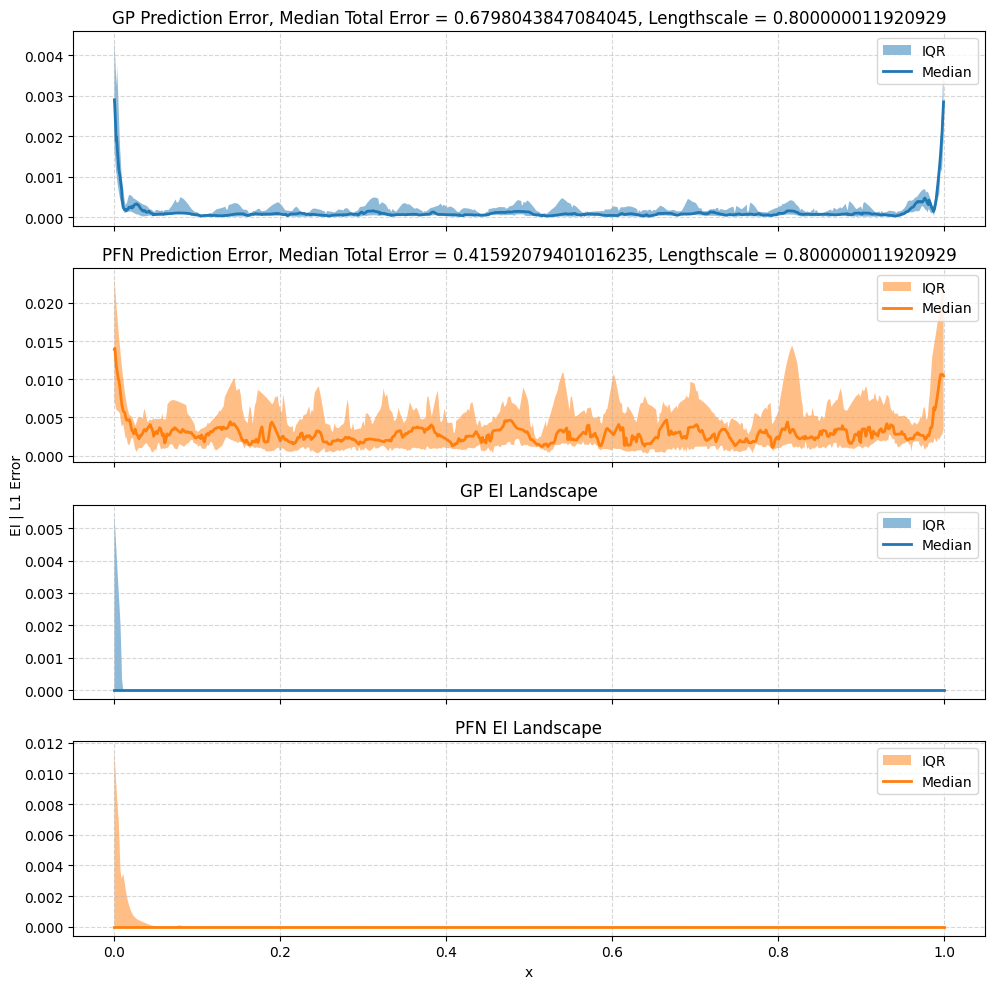

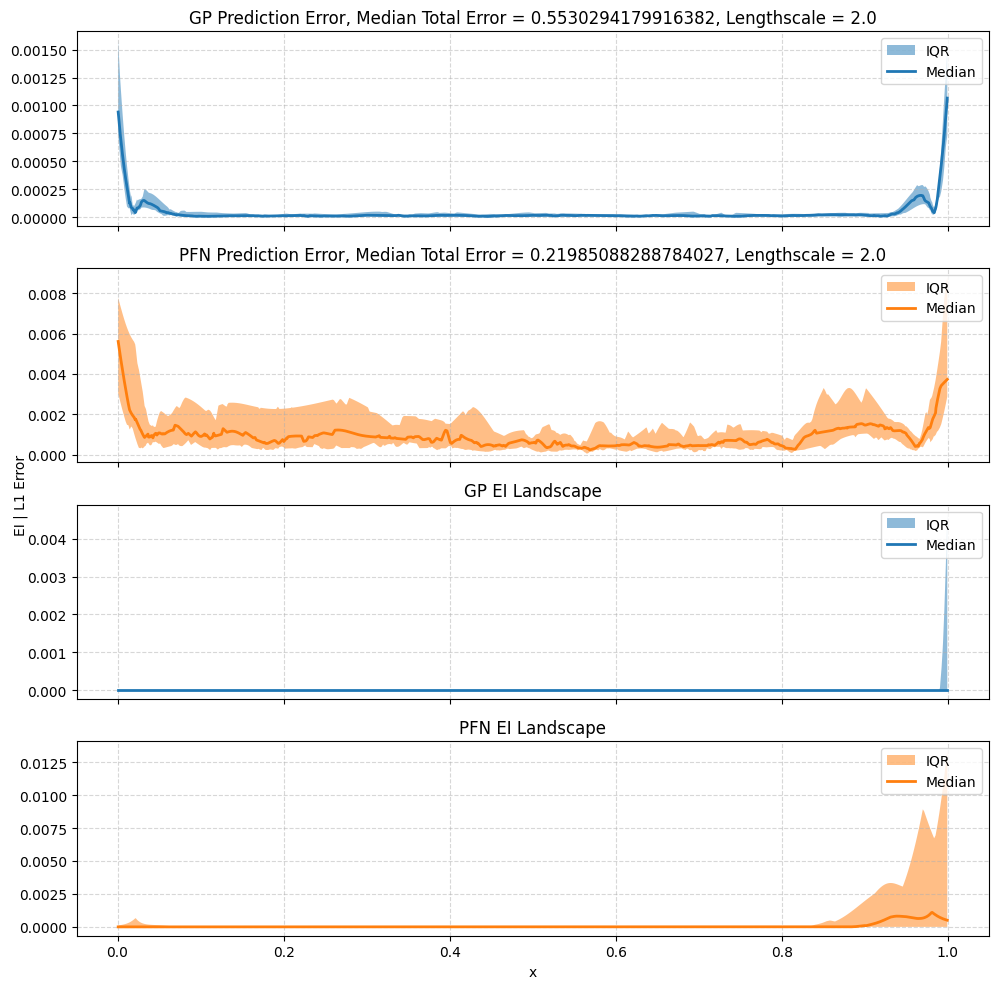

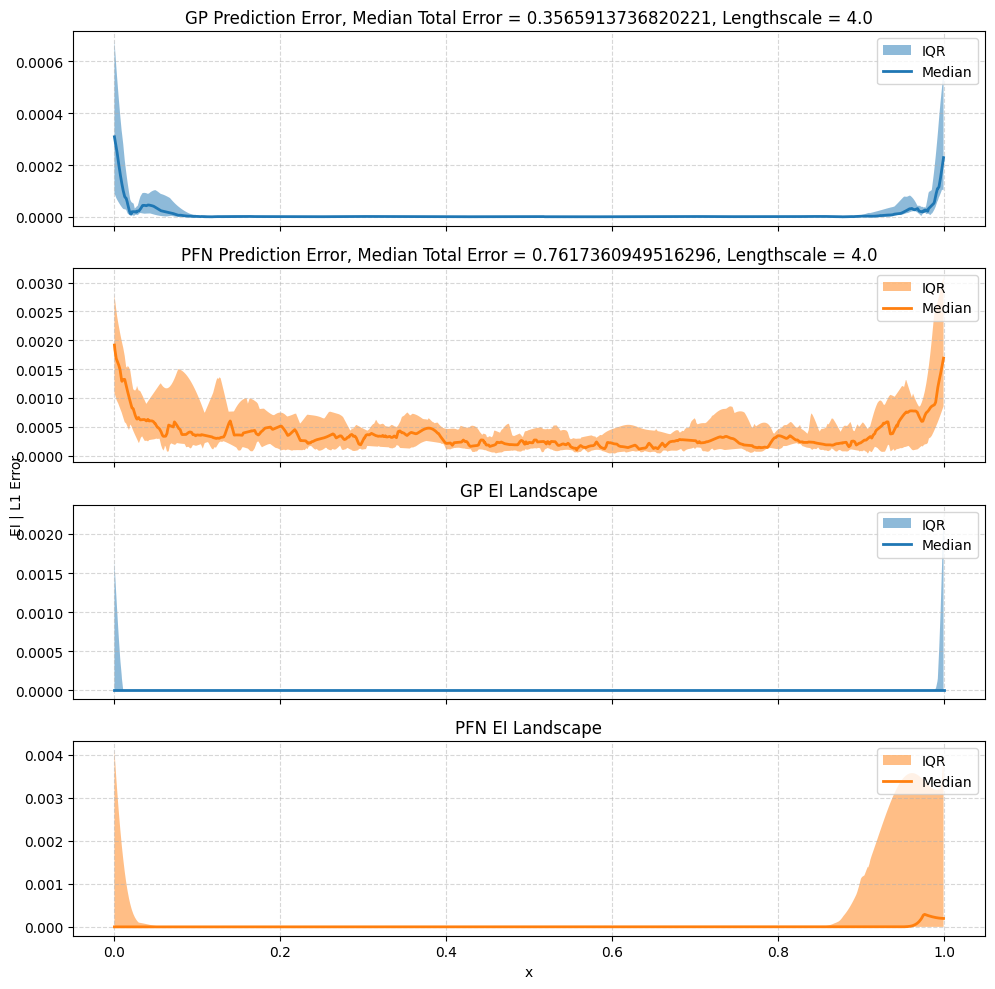

In [ ]:
for i in range(mu_data_GP.shape[0]):
    ls = ls_arr[0][i]
    
    pem_GP = pred_error_med[i, 0].squeeze(-1)
    tem_GP = total_error_med[i, 0].squeeze(-1)
    eim_GP = ei_med[i, 0].squeeze(-1)
    pelq_GP = pred_error_lq[i, 0].squeeze(-1)
    telq_GP = total_error_lq[i, 0].squeeze(-1)
    eilq_GP = ei_lq[i, 0].squeeze(-1)
    peuq_GP = pred_error_uq[i, 0].squeeze(-1)
    teuq_GP = total_error_uq[i, 0].squeeze(-1)
    eiuq_GP = ei_uq[i, 0].squeeze(-1)
    
    pem_PFN = pred_error_med[i, 1].squeeze(-1)
    tem_PFN = total_error_med[i, 1].squeeze(-1)
    eim_PFN = ei_med[i, 1].squeeze(-1)
    pelq_PFN = pred_error_lq[i, 1].squeeze(-1)
    telq_PFN = total_error_lq[i, 1].squeeze(-1)
    eilq_PFN = ei_lq[i, 1].squeeze(-1)
    peuq_PFN = pred_error_uq[i, 1].squeeze(-1)
    teuq_PFN = total_error_uq[i, 1].squeeze(-1)
    eiuq_PFN = ei_uq[i, 1].squeeze(-1)

    pem_PFN_W = pred_error_med[i, 2].squeeze(-1)
    tem_PFN_W = total_error_med[i, 2].squeeze(-1)
    eim_PFN_W = ei_med[i, 2].squeeze(-1)
    pelq_PFN_W = pred_error_lq[i, 2].squeeze(-1)
    telq_PFN_W = total_error_lq[i, 2].squeeze(-1)
    eilq_PFN_W = ei_lq[i, 2].squeeze(-1)
    peuq_PFN_W = pred_error_uq[i, 2].squeeze(-1)
    teuq_PFN_W = total_error_uq[i, 2].squeeze(-1)
    eiuq_PFN_W = ei_uq[i, 2].squeeze(-1)
    
    x_query_GP_plot = x_query_GP[i].squeeze(-1)
    x_query_PFN_plot = x_query_PFN[i].squeeze(-1)
    x_query_PFN_W_plot = x_query_PFN_W[i].squeeze(-1)

    sort_idx_GP = torch.argsort(x_query_GP_plot)
    x_query_GP_plot = x_query_GP_plot[sort_idx_GP]
    pem_GP = pem_GP[sort_idx_GP]
    eim_GP = eim_GP[sort_idx_GP]
    pelq_GP = pelq_GP[sort_idx_GP]
    eilq_GP = eilq_GP[sort_idx_GP]
    peuq_GP = peuq_GP[sort_idx_GP]
    eiuq_GP = eiuq_GP[sort_idx_GP]

    sort_idx_PFN = torch.argsort(x_query_PFN_plot)
    x_query_PFN_plot = x_query_PFN_plot[sort_idx_PFN]
    pem_PFN = pem_PFN[sort_idx_PFN]
    eim_PFN = eim_PFN[sort_idx_PFN]
    pelq_PFN = pelq_PFN[sort_idx_PFN]
    eilq_PFN = eilq_PFN[sort_idx_PFN]
    peuq_PFN = peuq_PFN[sort_idx_PFN]
    eiuq_PFN = eiuq_PFN[sort_idx_PFN]

    sort_idx_PFN_W = torch.argsort(x_query_PFN_W_plot)
    x_query_PFN_W_plot = x_query_PFN_W_plot[sort_idx_PFN_W]
    pem_PFN_W = pem_PFN_W[sort_idx_PFN_W]
    eim_PFN_W = eim_PFN_W[sort_idx_PFN_W]
    pelq_PFN_W = pelq_PFN_W[sort_idx_PFN_W]
    eilq_PFN_W = eilq_PFN_W[sort_idx_PFN_W]
    peuq_PFN_W = peuq_PFN_W[sort_idx_PFN_W]
    eiuq_PFN_W = eiuq_PFN_W[sort_idx_PFN_W]

    fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(
        nrows=6,
        ncols=1,
        figsize=(10, 10),
        sharex=True,
        sharey=False,
    )
    ax1.fill_between(
        x_query_GP_plot,
        pelq_GP,
        peuq_GP,
        color="tab:blue",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax1.plot(x_query_GP_plot, pem_GP, color="tab:blue", linewidth=2, label="Median")
    ax1.set_title(f"GP Prediction Error, Median Total Error = {tem_GP}, Lengthscale = {ls}")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper right")

    ax2.fill_between(
        x_query_PFN_plot,
        pelq_PFN,
        peuq_PFN,
        color="tab:orange",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax2.plot(x_query_PFN_plot, pem_PFN, color="tab:orange", linewidth=2, label="Median")
    ax2.set_title(f"PFN Prediction Error, Median Total Error = {tem_PFN}, Lengthscale = {ls}")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc="upper right")

    ax3.fill_between(
        x_query_PFN_W_plot,
        pelq_PFN_W,
        peuq_PFN_W,
        color="tab:green",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax3.plot(x_query_PFN_W_plot, pem_PFN_W, color="tab:green", linewidth=2, label="Median")
    ax3.set_title(f"Warped PFN Prediction Error, Median Total Error = {tem_PFN_W}, Lengthscale = {ls}")
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper right")

    ax4.fill_between(
        x_query_GP_plot,
        np.clip(eilq_GP, 1e-12, None),
        np.clip(eiuq_GP, 1e-12, None),
        color="tab:blue",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax4.plot(x_query_GP_plot, eim_GP, color="tab:blue", linewidth=2, label="Median")
    ax4.set_title("GP EI Landscape")
    ax4.set_yscale("log")
    ax4.grid(True, linestyle="--", alpha=0.5)
    ax4.legend(loc="upper right")

    ax5.fill_between(
        x_query_PFN_plot,
        np.clip(eilq_PFN, 1e-12, None),
        np.clip(eiuq_PFN, 1e-12, None),
        color="tab:orange",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax5.plot(x_query_PFN_plot, eim_PFN, color="tab:orange", linewidth=2, label="Median")
    ax5.set_title("PFN EI Landscape")
    ax5.set_yscale("log")
    ax5.grid(True, linestyle="--", alpha=0.5)
    ax5.legend(loc="upper right")

    ax6.fill_between(
        x_query_PFN_W_plot,
        np.clip(eilq_PFN_W, 1e-12, None),
        np.clip(eiuq_PFN_W, 1e-12, None),
        color="tab:green",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax6.plot(x_query_PFN_W_plot, eim_PFN_W, color="tab:green", linewidth=2, label="Median")
    ax6.set_title("Warped PFN EI Landscape")
    ax6.set_yscale("log")
    ax6.grid(True, linestyle="--", alpha=0.5)
    ax6.legend(loc="upper right")

    ax6.set_xlabel("x")
    fig.text(0.01, 0.5, "EI | L1 Error", va="center", rotation="vertical")

    plt.tight_layout()
    plt.show()

In [ ]:
# metrics["pred_error"][test, k, m_idx, rep, :, :]
# 9 tests, 1 dim, 2 methods, 21 reps, 1000 samples, dim = 1 -> 9 tests, 3 methods, 1000 samples, 1 
gll_med = torch.quantile(torch.sum(gll[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.5, dim=-3)
mgll_med = torch.quantile(m_gll[:, 0, :, :, :], 0.5, dim=-3)

gll_lq = torch.quantile(torch.sum(gll[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.25, dim=-3)
mgll_lq = torch.quantile(m_gll[:, 0, :, :, :], 0.25, dim=-3)

gll_uq = torch.quantile(torch.sum(gll[:, 0, :, :, :, :], dim=-1, keepdim=True), 0.75, dim=-3)
mgll_uq = torch.quantile(m_gll[:, 0, :, :, :], 0.75, dim=-3)

In [ ]:
for i in range(mu_data_GP.shape[0]):
    ls = ls_arr[0][i]
    
    gllm_GP = gll_med[i, 0].squeeze(-1)
    mgllm_GP = mgll_med[i, 0].squeeze(-1)
    glllq_GP = gll_lq[i, 0].squeeze(-1)
    mglllq_GP = mgll_lq[i, 0].squeeze(-1)
    glluq_GP = gll_uq[i, 0].squeeze(-1)
    mglluq_GP = mgll_uq[i, 0].squeeze(-1)
    
    gllm_PFN = gll_med[i, 1].squeeze(-1)
    mgllm_PFN = mgll_med[i, 1].squeeze(-1)
    glllq_PFN = gll_lq[i, 1].squeeze(-1)
    mglllq_PFN = mgll_lq[i, 1].squeeze(-1)
    glluq_PFN = gll_uq[i, 1].squeeze(-1)
    mglluq_PFN = mgll_uq[i, 1].squeeze(-1)

    gllm_PFN_W = gll_med[i, 2].squeeze(-1)
    mgllm_PFN_W = mgll_med[i, 2].squeeze(-1)
    glllq_PFN_W = gll_lq[i, 2].squeeze(-1)
    mglllq_PFN_W = mgll_lq[i, 2].squeeze(-1)
    glluq_PFN_W = gll_uq[i, 2].squeeze(-1)
    mglluq_PFN_W = mgll_uq[i, 2].squeeze(-1)
    
    x_query_GP_plot = x_query_GP[i].squeeze(-1)
    x_query_PFN_plot = x_query_PFN[i].squeeze(-1)
    x_query_PFN_W_plot = x_query_PFN_W[i].squeeze(-1)

    sort_idx_GP = torch.argsort(x_query_GP_plot)
    x_query_GP_plot = x_query_GP_plot[sort_idx_GP]
    gllm_GP = gllm_GP[sort_idx_GP]
    glllq_GP = glllq_GP[sort_idx_GP]
    glluq_GP = glluq_GP[sort_idx_GP]

    sort_idx_PFN = torch.argsort(x_query_PFN_plot)
    x_query_PFN_plot = x_query_PFN_plot[sort_idx_PFN]
    gllm_PFN = gllm_PFN[sort_idx_PFN]
    glllq_PFN = glllq_PFN[sort_idx_PFN]
    glluq_PFN = glluq_PFN[sort_idx_PFN]

    sort_idx_PFN_W = torch.argsort(x_query_PFN_W_plot)
    x_query_PFN_W_plot = x_query_PFN_W_plot[sort_idx_PFN_W]
    gllm_PFN_W = gllm_PFN_W[sort_idx_PFN_W]
    glllq_PFN_W = glllq_PFN_W[sort_idx_PFN_W]
    glluq_PFN_W = glluq_PFN_W[sort_idx_PFN_W]

    fig, (ax1, ax2, ax3) = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(10, 10),
        sharex=True,
        sharey=False,
    )
    ax1.fill_between(
        x_query_GP_plot,
        glllq_GP,
        glluq_GP,
        color="tab:blue",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax1.plot(x_query_GP_plot, gllm_GP, color="tab:blue", linewidth=2, label="Median")
    ax1.set_title(f"GP Prediction Log Likelyhood, Median Mean Prediction Log Likelyhood = {mgllm_GP}, Lengthscale = {ls}")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper right")

    ax2.fill_between(
        x_query_PFN_plot,
        glllq_PFN,
        glluq_PFN,
        color="tab:orange",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax2.plot(x_query_PFN_plot, gllm_PFN, color="tab:orange", linewidth=2, label="Median")
    ax2.set_title(f"PFN Prediction Log Likelyhood, Median Mean Prediction Log Likelyhood = {mgllm_PFN}, Lengthscale = {ls}")
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc="upper right")

    ax3.fill_between(
        x_query_PFN_W_plot,
        glllq_PFN_W,
        glluq_PFN_W,
        color="tab:green",
        alpha=0.5,
        edgecolor="none",
        label="IQR",
    )
    ax3.plot(x_query_PFN_W_plot, gllm_PFN_W, color="tab:green", linewidth=2, label="Median")
    ax3.set_title(f"Warped PFN Prediction Log Likelyhood, Median Mean Prediction Log Likelyhood = {mgllm_PFN_W}, Lengthscale = {ls}")
    ax3.grid(True, linestyle="--", alpha=0.5)
    ax3.legend(loc="upper right")

    ax3.set_xlabel("x")
    fig.text(0.01, 0.5, "Log Likelyhood", va="center", rotation="vertical")

    plt.tight_layout()
    plt.show()

In [ ]:
ls = ls_arr[0][:]

mgllm_GP = mgll_med[:, 0].squeeze(-1)
mglllq_GP = mgll_lq[:, 0].squeeze(-1)
mglluq_GP = mgll_uq[:, 0].squeeze(-1)

mgllm_PFN = mgll_med[:, 1].squeeze(-1)
mglllq_PFN = mgll_lq[:, 1].squeeze(-1)
mglluq_PFN = mgll_uq[:, 1].squeeze(-1)

mgllm_PFN_W = mgll_med[:, 2].squeeze(-1)
mglllq_PFN_W = mgll_lq[:, 2].squeeze(-1)
mglluq_PFN_W = mgll_uq[:, 2].squeeze(-1)

tem_GP = total_error_med[:, 0].squeeze(-1)
telq_GP = total_error_lq[:, 0].squeeze(-1)
teuq_GP = total_error_uq[:, 0].squeeze(-1)

tem_PFN = total_error_med[:, 1].squeeze(-1)
telq_PFN = total_error_lq[:, 1].squeeze(-1)
teuq_PFN = total_error_uq[:, 1].squeeze(-1)

tem_PFN_W = total_error_med[:, 2].squeeze(-1)
telq_PFN_W = total_error_lq[:, 2].squeeze(-1)
teuq_PFN_W = total_error_uq[:, 2].squeeze(-1)

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 10),
    sharex=True,
    sharey=False,
)
ax1.fill_between(
    ls,
    tem_GP,
    tem_GP,
    color="tab:blue",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax1.plot(ls, tem_GP, color="tab:blue", linewidth=2, label="Median")
ax1.set_title(f"GP Prediction Error")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right")

ax1.fill_between(
    ls,
    tem_PFN,
    tem_PFN,
    color="tab:orange",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax1.plot(ls, tem_PFN, color="tab:orange", linewidth=2, label="Median")
ax1.set_title(f"PFN Prediction Error")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right")

ax1.fill_between(
    ls,
    tem_PFN_W,
    tem_PFN_W,
    color="tab:green",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax1.plot(ls, tem_PFN_W, color="tab:green", linewidth=2, label="Median")
ax1.set_title(f"PFN Prediction Error")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right")

ax2.fill_between(
    ls,
    glllq_GP,
    glluq_GP,
    color="tab:blue",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax2.plot(ls, gllm_GP, color="tab:blue", linewidth=2, label="Median")
ax2.set_title(f"GP Log Likelyhood")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

ax2.fill_between(
    ls,
    glllq_PFN,
    glluq_PFN,
    color="tab:orange",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax2.plot(ls, gllm_PFN, color="tab:orange", linewidth=2, label="Median")
ax2.set_title(f"PFN Log Likelyhood")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

ax2.fill_between(
    ls,
    glllq_PFN_W,
    glluq_PFN_W,
    color="tab:green",
    alpha=0.5,
    edgecolor="none",
    label="IQR",
)
ax2.plot(ls, gllm_PFN_W, color="tab:green", linewidth=2, label="Median")
ax2.set_title(f"PFN Log Likelyhood")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

ax2.set_xlabel("x")
fig.text(0.01, 0.5, "Log Likelyhood", va="center", rotation="vertical")

plt.tight_layout()
plt.show()